# Đồ án Khai phá dữ liệu – Nhóm 13
**Đề tài:** Ứng dụng kỹ thuật gom nhóm trong khai thác dữ liệu khách hàng để phân khúc thị trường

**Môn học:** Khai phá dữ liệu | **GVHD:** ThS. Nguyễn Thị Huyền Trang

---
**Nội dung notebook:**
1. Cài đặt thư viện
2. Import thư viện
3. Upload dữ liệu
4. Đọc & làm sạch dữ liệu
5. EDA – Phân tích khám phá
6. Phát hiện ngoại lệ (Outlier Detection)
7. Xây dựng đặc trưng RFM + Phân phối
8. Chuẩn hóa đặc trưng
9. Elbow Method + Silhouette → chọn K tối ưu
10. K-Means Clustering
11. K-Distance Plot + DBSCAN
12. Đánh giá & So sánh K-Means vs DBSCAN
13. Đặt tên phân khúc + Chiến lược Marketing
14. Trực quan hóa: PCA · Boxplot · Radar Chart
15. Chạy toàn bộ pipeline
16. Giao diện Gradio

## 1. Cài đặt thư viện
Chạy ô này trước. Nếu Colab yêu cầu restart sau khi cài đặt, hãy restart rồi chạy lại từ ô 2.

In [ ]:
!pip -q install gradio openpyxl scikit-learn kneed

## 2. Import thư viện

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os, io, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score)
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

try:
    from kneed import KneeLocator
except Exception:
    KneeLocator = None

import gradio as gr

print("✓ Import thư viện thành công")

✓ Import thư viện thành công


## 3. Upload dữ liệu trên Colab
**Cách dùng:**
1. Bấm nút chạy ô dưới.
2. Upload file `Online Retail.xlsx`.
3. Biến `DATA_PATH` sẽ chứa đường dẫn file.

> Nếu dùng giao diện Gradio ở cuối notebook thì bỏ qua ô này.

In [ ]:
try:
    from google.colab import files
    uploaded = files.upload()
    if len(uploaded) > 0:
        DATA_PATH = list(uploaded.keys())[0]
        print("Đã upload:", DATA_PATH)
    else:
        DATA_PATH = "Online Retail.xlsx"
except Exception:
    DATA_PATH = "Online Retail.xlsx"
    print("Không chạy trên Colab hoặc chưa upload. DATA_PATH mặc định:", DATA_PATH)

Saving Online Retail.xlsx to Online Retail.xlsx
Đã upload: Online Retail.xlsx


## 4. Đọc và làm sạch dữ liệu
**Quy tắc làm sạch:**
- Bỏ dòng thiếu `CustomerID` (không thể tính RFM).
- Bỏ giao dịch bị hủy (`InvoiceNo` bắt đầu bằng `'C'`).
- Bỏ dòng `Quantity <= 0` hoặc `UnitPrice <= 0`.
- Tạo cột `TotalAmount = Quantity × UnitPrice`.

In [ ]:
def read_online_retail(file_path_or_obj):
    """Đọc file Online Retail từ đường dẫn hoặc file-like object."""
    df = pd.read_excel(file_path_or_obj, engine="openpyxl")
    df.columns = [str(c).strip() for c in df.columns]
    return df


def clean_online_retail(df):
    """Làm sạch dữ liệu giao dịch Online Retail."""
    required_cols = ["InvoiceNo", "Quantity", "InvoiceDate", "UnitPrice", "CustomerID"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Thiếu cột bắt buộc: {missing}")

    data = df.copy()
    original_rows = len(data)

    data["InvoiceNo"]   = data["InvoiceNo"].astype(str)
    data["InvoiceDate"] = pd.to_datetime(data["InvoiceDate"], errors="coerce")
    data["Quantity"]    = pd.to_numeric(data["Quantity"],    errors="coerce")
    data["UnitPrice"]   = pd.to_numeric(data["UnitPrice"],   errors="coerce")

    n_missing_cust = data["CustomerID"].isna().sum()
    data = data.dropna(subset=["CustomerID", "InvoiceDate", "Quantity", "UnitPrice"])

    n_cancelled = data["InvoiceNo"].str.upper().str.startswith("C").sum()
    data = data[~data["InvoiceNo"].str.upper().str.startswith("C")]

    n_invalid = ((data["Quantity"] <= 0) | (data["UnitPrice"] <= 0)).sum()
    data = data[(data["Quantity"] > 0) & (data["UnitPrice"] > 0)]

    data["CustomerID"]  = data["CustomerID"].astype(int).astype(str)
    data["TotalAmount"] = data["Quantity"] * data["UnitPrice"]

    cleaning_report = {
        "Số dòng ban đầu":          original_rows,
        "Thiếu CustomerID (bỏ)":    int(n_missing_cust),
        "Giao dịch hủy (bỏ)":       int(n_cancelled),
        "Quantity/Price <= 0 (bỏ)": int(n_invalid),
        "Số dòng sau làm sạch":      len(data),
        "Số khách hàng":             data["CustomerID"].nunique(),
        "Số hóa đơn":                data["InvoiceNo"].nunique(),
        "Từ ngày":                   data["InvoiceDate"].min().date(),
        "Đến ngày":                  data["InvoiceDate"].max().date(),
    }
    return data, cleaning_report

## 5. EDA – Phân tích khám phá dữ liệu
Trước khi mô hình hóa, cần hiểu cấu trúc dữ liệu:
- **Top 10 quốc gia** theo doanh thu.
- **Doanh thu theo tháng** – phát hiện xu hướng mùa vụ.
- **Top 10 sản phẩm** bán chạy nhất.

In [ ]:
def plot_eda(data):
    """Vẽ 3 biểu đồ EDA tổng quan."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("EDA – Phân tích khám phá dữ liệu", fontsize=14, fontweight="bold")

    # Top 10 quốc gia theo doanh thu
    if "Country" in data.columns:
        country_rev = (data.groupby("Country")["TotalAmount"]
                       .sum().sort_values(ascending=False).head(10))
        axes[0].barh(country_rev.index[::-1], country_rev.values[::-1], color="#5E81F4")
        axes[0].set_title("Top 10 quốc gia theo doanh thu")
        axes[0].set_xlabel("Tổng doanh thu (£)")
        axes[0].grid(axis="x", alpha=0.3)

    # Doanh thu theo tháng
    data = data.copy()
    data["YearMonth"] = data["InvoiceDate"].dt.to_period("M")
    monthly = data.groupby("YearMonth")["TotalAmount"].sum()
    axes[1].plot(monthly.index.astype(str), monthly.values, marker="o", color="#F4A261")
    axes[1].set_title("Doanh thu theo tháng")
    axes[1].set_xlabel("Tháng")
    axes[1].set_ylabel("Tổng doanh thu (£)")
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].grid(True, alpha=0.3)

    # Top 10 sản phẩm
    if "Description" in data.columns:
        top_prod = (data.groupby("Description")["Quantity"]
                    .sum().sort_values(ascending=False).head(10))
        axes[2].barh(top_prod.index[::-1], top_prod.values[::-1], color="#2EC4B6")
        axes[2].set_title("Top 10 sản phẩm (theo số lượng)")
        axes[2].set_xlabel("Tổng số lượng bán")
        axes[2].grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()
    print("[EDA] Hoàn tất.")

## 6. Phát hiện ngoại lệ (Outlier Detection)
Dữ liệu Online Retail có phân phối **Monetary rất lệch phải** – một số khách hàng chi tiêu hàng chục nghìn £.
Nếu không xử lý, K-Means sẽ bị kéo tâm cụm sai.

**Phương pháp:** IQR × 3.0 (ngưỡng mở rộng để chỉ loại outlier cực đoan).

In [ ]:
def plot_outlier_boxplot(rfm):
    """Boxplot R, F, M để nhận diện ngoại lệ."""
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    fig.suptitle("Boxplot RFM – Phát hiện ngoại lệ", fontsize=13, fontweight="bold")
    cols   = ["Recency", "Frequency", "Monetary"]
    colors = ["#E76F51", "#2A9D8F", "#264653"]
    for i, (col, c) in enumerate(zip(cols, colors)):
        axes[i].boxplot(rfm[col], patch_artist=True,
                        boxprops=dict(facecolor=c, alpha=0.5),
                        medianprops=dict(color="black", linewidth=2),
                        whiskerprops=dict(linewidth=1.2),
                        flierprops=dict(marker="o", markersize=3, alpha=0.4))
        axes[i].set_title(col)
        axes[i].set_ylabel(col)
        axes[i].grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


def remove_outliers_iqr(rfm, cols=("Monetary",), factor=3.0):
    """Loại outlier cực đoan bằng IQR với factor mở rộng (mặc định 3.0)."""
    mask = pd.Series([True] * len(rfm), index=rfm.index)
    for col in cols:
        Q1, Q3 = rfm[col].quantile(0.25), rfm[col].quantile(0.75)
        IQR    = Q3 - Q1
        lower, upper = Q1 - factor * IQR, Q3 + factor * IQR
        col_mask = rfm[col].between(lower, upper)
        print(f"  [{col}] IQR×{factor}: loại {(~col_mask).sum()} khách hàng "
              f"(ngoài [{lower:.1f}, {upper:.1f}])")
        mask = mask & col_mask
    rfm_clean = rfm[mask].copy()
    print(f"  → Trước: {len(rfm)} | Sau: {len(rfm_clean)} khách hàng")
    return rfm_clean

## 7. Xây dựng đặc trưng RFM
| Chỉ số | Công thức | Ý nghĩa |
|--------|-----------|---------|
| **Recency (R)** | Ngày mốc − ngày mua cuối | Càng nhỏ càng tốt |
| **Frequency (F)** | Số hóa đơn duy nhất | Càng lớn càng tốt |
| **Monetary (M)** | Tổng `Quantity × UnitPrice` | Càng lớn càng tốt |

Sau đó vẽ **histogram trước/sau log-transform** để thấy hiệu quả xử lý độ lệch.

In [ ]:
def build_rfm(data):
    """Tạo bảng RFM theo CustomerID."""
    snapshot_date = data["InvoiceDate"].max() + pd.Timedelta(days=1)

    agg_dict = {
        "Recency":      ("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
        "Frequency":    ("InvoiceNo",   "nunique"),
        "Monetary":     ("TotalAmount", "sum"),
        "LastPurchase": ("InvoiceDate", "max"),
    }
    if "Country" in data.columns:
        agg_dict["Country"] = (
            "Country", lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else "Unknown"
        )

    rfm = data.groupby("CustomerID").agg(**agg_dict).reset_index()
    rfm = rfm[rfm["Monetary"] > 0].copy()

    # Điểm RFM 1-5 (Recency đảo chiều: thấp = điểm cao)
    rfm["R_Score"] = pd.qcut(rfm["Recency"].rank(method="first"),   5, labels=[5,4,3,2,1]).astype(int)
    rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)
    rfm["M_Score"] = pd.qcut(rfm["Monetary"].rank(method="first"),  5, labels=[1,2,3,4,5]).astype(int)
    rfm["RFM_Score"] = rfm["R_Score"].astype(str) + rfm["F_Score"].astype(str) + rfm["M_Score"].astype(str)
    rfm["RFM_Total"] = rfm[["R_Score", "F_Score", "M_Score"]].sum(axis=1)
    return rfm, snapshot_date


def plot_rfm_distribution(rfm):
    """Histogram R, F, M trước và sau log-transform."""
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    fig.suptitle("Phân phối RFM trước và sau log-transform", fontsize=13, fontweight="bold")
    cols   = ["Recency", "Frequency", "Monetary"]
    colors = ["#E76F51", "#2A9D8F", "#264653"]
    for i, (col, c) in enumerate(zip(cols, colors)):
        axes[0, i].hist(rfm[col], bins=50, color=c, edgecolor="white", linewidth=0.3)
        axes[0, i].set_title(f"{col} (gốc)")
        axes[0, i].set_xlabel(col); axes[0, i].set_ylabel("Tần số")
        axes[0, i].grid(True, alpha=0.3)

        axes[1, i].hist(np.log1p(rfm[col]), bins=50, color=c, edgecolor="white",
                        linewidth=0.3, alpha=0.8)
        axes[1, i].set_title(f"log1p({col})")
        axes[1, i].set_xlabel(f"log1p({col})"); axes[1, i].set_ylabel("Tần số")
        axes[1, i].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 8. Chuẩn hóa đặc trưng
**Quy trình 2 bước:**
1. `np.log1p()` – giảm độ lệch phân phối.
2. `StandardScaler` – đưa về mean=0, std=1 để các thuật toán khoảng cách không bị thiên vị.

In [ ]:
def prepare_features(rfm):
    """Log-transform và chuẩn hóa RFM bằng StandardScaler."""
    features     = rfm[["Recency", "Frequency", "Monetary"]].copy()
    features_log = np.log1p(features)
    scaler       = StandardScaler()
    X_scaled     = scaler.fit_transform(features_log)
    return features, features_log, X_scaled, scaler

## 9. Elbow Method + Silhouette Score → Chọn K tối ưu
Hai phương pháp kết hợp để xác định số cụm K tốt nhất:
- **Elbow Method (WCSS):** Tìm điểm "gãy khuỷu tay" – sau điểm đó, giảm WCSS không còn đáng kể.
- **Silhouette Score:** Đo mức độ phân tách cụm, càng gần 1 càng tốt.

In [ ]:
def evaluate_kmeans(X_scaled, k_min=2, k_max=10, random_state=42):
    """Tính WCSS, Silhouette, Davies-Bouldin, Calinski-Harabasz cho K từ k_min đến k_max."""
    max_k = min(k_max, len(X_scaled) - 1)
    rows  = []
    for k in range(k_min, max_k + 1):
        model  = KMeans(n_clusters=k, random_state=random_state, n_init=20)
        labels = model.fit_predict(X_scaled)
        rows.append({
            "K":                 k,
            "WCSS/Inertia":      round(model.inertia_, 2),
            "Silhouette":        round(silhouette_score(X_scaled, labels), 4),
            "Davies_Bouldin":    round(davies_bouldin_score(X_scaled, labels), 4),
            "Calinski_Harabasz": round(calinski_harabasz_score(X_scaled, labels), 1),
        })
    result            = pd.DataFrame(rows)
    best_k_silhouette = int(result.loc[result["Silhouette"].idxmax(), "K"])
    elbow_k = None
    if KneeLocator is not None and len(result) >= 3:
        try:
            kl      = KneeLocator(result["K"], result["WCSS/Inertia"],
                                  curve="convex", direction="decreasing")
            elbow_k = int(kl.elbow) if kl.elbow else None
        except Exception:
            pass
    return result, best_k_silhouette, elbow_k


def plot_kmeans_evaluation(eval_df, best_k=None, elbow_k=None):
    """Vẽ Elbow Method và Silhouette Score song song."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Đánh giá số cụm K tối ưu cho K-Means", fontsize=13, fontweight="bold")

    # Elbow
    axes[0].plot(eval_df["K"], eval_df["WCSS/Inertia"], marker="o", color="#5E81F4", linewidth=2)
    if elbow_k:
        y_e = eval_df.loc[eval_df["K"] == elbow_k, "WCSS/Inertia"].values[0]
        axes[0].axvline(elbow_k, color="red", linestyle="--", alpha=0.7, label=f"Elbow K={elbow_k}")
        axes[0].scatter([elbow_k], [y_e], color="red", s=80, zorder=5)
        axes[0].legend()
    axes[0].set_title("Elbow Method – WCSS/Inertia")
    axes[0].set_xlabel("Số cụm K"); axes[0].set_ylabel("WCSS/Inertia")
    axes[0].grid(True, alpha=0.3)

    # Silhouette
    axes[1].plot(eval_df["K"], eval_df["Silhouette"], marker="o", color="#F4A261", linewidth=2)
    if best_k:
        y_s = eval_df.loc[eval_df["K"] == best_k, "Silhouette"].values[0]
        axes[1].axvline(best_k, color="green", linestyle="--", alpha=0.7, label=f"Best K={best_k}")
        axes[1].scatter([best_k], [y_s], color="green", s=80, zorder=5)
        axes[1].legend()
    axes[1].set_title("Silhouette Score theo K")
    axes[1].set_xlabel("Số cụm K"); axes[1].set_ylabel("Silhouette Score")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## 10. K-Means Clustering

In [ ]:
def run_kmeans(rfm, X_scaled, n_clusters=4, random_state=42):
    """Chạy K-Means và gán nhãn cụm vào DataFrame RFM."""
    result = rfm.copy()
    model  = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=20)
    result["Cluster"] = model.fit_predict(X_scaled)
    return result, model

## 11. K-Distance Plot + DBSCAN
**Cách chọn tham số `eps`:**
1. Tính khoảng cách đến láng giềng thứ `min_samples` cho mỗi điểm.
2. Sắp xếp tăng dần → vẽ k-distance plot.
3. Chọn `eps` tại điểm "gãy" (elbow) của đồ thị.

> Điểm nằm dưới ngưỡng eps → lõi cụm; điểm nằm trên → nhiễu (nhãn `-1`).

In [ ]:
def suggest_dbscan_eps(X_scaled, min_samples=5):
    """Vẽ K-Distance Plot và gợi ý eps tại điểm gãy."""
    neigh = NearestNeighbors(n_neighbors=min_samples)
    neigh.fit(X_scaled)
    distances, _ = neigh.kneighbors(X_scaled)
    k_distances   = np.sort(distances[:, -1])

    suggested_eps = float(np.percentile(k_distances, 92))
    if KneeLocator is not None:
        try:
            kl = KneeLocator(range(len(k_distances)), k_distances,
                             curve="convex", direction="increasing")
            if kl.knee is not None:
                suggested_eps = float(k_distances[kl.knee])
        except Exception:
            pass

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(k_distances, color="#264653", linewidth=1.2)
    ax.axhline(suggested_eps, color="red", linestyle="--", alpha=0.8,
               label=f"Gợi ý eps = {suggested_eps:.3f}")
    ax.set_title(f"K-Distance Plot (k={min_samples}) – Chọn eps cho DBSCAN")
    ax.set_xlabel("Các điểm dữ liệu (đã sắp xếp theo khoảng cách)")
    ax.set_ylabel(f"Khoảng cách đến láng giềng thứ {min_samples}")
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"  Eps gợi ý: {suggested_eps:.4f}  — Điều chỉnh nếu cần sau khi xem đồ thị.")
    return suggested_eps, k_distances


def run_dbscan(rfm, X_scaled, eps=0.8, min_samples=8):
    """Chạy DBSCAN và gán nhãn cụm vào DataFrame RFM."""
    result = rfm.copy()
    model  = DBSCAN(eps=eps, min_samples=min_samples)
    result["Cluster"] = model.fit_predict(X_scaled)
    return result, model

## 12. Đánh giá & So sánh K-Means vs DBSCAN
| Chỉ số | Hướng tốt hơn | Ý nghĩa |
|--------|--------------|---------|
| **Silhouette Score** | Càng **cao** càng tốt (max 1.0) | Đo mức độ phân tách cụm |
| **Davies-Bouldin** | Càng **thấp** càng tốt (min 0) | Tỷ lệ phân tán nội cụm / khoảng cách liên cụm |
| **Calinski-Harabasz** | Càng **cao** càng tốt | Tỷ lệ phương sai liên cụm / nội cụm |

In [ ]:
def evaluate_clustering(X_scaled, labels, algo_name=""):
    """
    Đánh giá chất lượng gom cụm.
    Với DBSCAN: loại bỏ nhiễu (nhãn -1) trước khi tính metrics.
    """
    labels        = np.array(labels)
    n_clusters    = len(set(labels) - {-1})
    n_noise       = int(np.sum(labels == -1))
    metrics = {
        "Thuật toán":         algo_name,
        "Số cụm thực tế":     n_clusters,
        "Số điểm nhiễu (-1)": n_noise,
        "Tỷ lệ nhiễu (%)":    round(n_noise / len(labels) * 100, 2),
    }
    valid_mask   = labels != -1
    valid_labels = labels[valid_mask]
    valid_X      = X_scaled[valid_mask]
    if len(set(valid_labels)) >= 2 and len(valid_X) > len(set(valid_labels)):
        metrics["Silhouette"]        = round(float(silhouette_score(valid_X, valid_labels)), 4)
        metrics["Davies_Bouldin"]    = round(float(davies_bouldin_score(valid_X, valid_labels)), 4)
        metrics["Calinski_Harabasz"] = round(float(calinski_harabasz_score(valid_X, valid_labels)), 1)
    else:
        metrics["Silhouette"] = metrics["Davies_Bouldin"] = metrics["Calinski_Harabasz"] = None
    return metrics


def compare_algorithms(kmeans_metrics, dbscan_metrics):
    """In bảng so sánh K-Means vs DBSCAN song song."""
    keys = ["Số cụm thực tế", "Số điểm nhiễu (-1)", "Tỷ lệ nhiễu (%)",
            "Silhouette", "Davies_Bouldin", "Calinski_Harabasz"]
    rows = [{"Chỉ số": k,
             "K-Means": kmeans_metrics.get(k),
             "DBSCAN":  dbscan_metrics.get(k)} for k in keys]
    df = pd.DataFrame(rows)
    print("\n========== SO SÁNH K-MEANS vs DBSCAN ==========")
    print(df.to_string(index=False))
    print("\nGhi chú: Silhouette & Calinski_Harabasz càng cao càng tốt; "
          "Davies_Bouldin càng thấp càng tốt.")
    return df

## 13. Đặt tên phân khúc + Chiến lược Marketing
Chuyển kết quả kỹ thuật thành ý nghĩa kinh doanh thực tiễn.

> **Lưu ý quan trọng (đã sửa):** Điểm nhiễu `-1` của DBSCAN được loại ra trước khi gán tên phân khúc.

In [ ]:
def assign_segment_names(cluster_profile):
    """
    Gán tên phân khúc dựa trên trung bình RFM.
    Đã xử lý edge case: chỉ 1 cụm, cụm trùng nhau.
    """
    profile = cluster_profile.copy()
    profile["SegmentName"]       = "Khách hàng trung bình"
    profile["MarketingStrategy"] = "Duy trì chăm sóc định kỳ, gửi ưu đãi theo lịch sử mua hàng."

    if len(profile) <= 1:
        return profile

    r_rank = profile["Recency_mean"].rank(ascending=True)    # thấp = tốt
    f_rank = profile["Frequency_mean"].rank(ascending=False) # cao  = tốt
    m_rank = profile["Monetary_mean"].rank(ascending=False)  # cao  = tốt
    score  = r_rank + f_rank + m_rank
    used   = set()

    # VIP: điểm tổng hợp tốt nhất
    best = score.idxmin()
    profile.loc[best, "SegmentName"]       = "Khách hàng VIP / Trung thành"
    profile.loc[best, "MarketingStrategy"] = (
        "Ưu tiên chăm sóc riêng, chương trình thành viên, voucher độc quyền, giữ chân dài hạn.")
    used.add(best)

    # Nguy cơ rời bỏ: Recency cao + Frequency thấp
    remaining = profile.drop(index=list(used))
    if len(remaining) > 0:
        at_risk_score = (remaining["Recency_mean"].rank(ascending=False) +
                         remaining["Frequency_mean"].rank(ascending=True))
        at_risk = at_risk_score.idxmin()
        profile.loc[at_risk, "SegmentName"]       = "Khách hàng có nguy cơ rời bỏ"
        profile.loc[at_risk, "MarketingStrategy"] = (
            "Gửi ưu đãi quay lại, email nhắc mua, khảo sát lý do ngừng mua.")
        used.add(at_risk)

    # Giá trị cao: Monetary cao nhất (ngoài VIP)
    remaining = profile.drop(index=list(used))
    if len(remaining) > 0:
        high_val = remaining["Monetary_mean"].idxmax()
        profile.loc[high_val, "SegmentName"]       = "Khách hàng giá trị cao"
        profile.loc[high_val, "MarketingStrategy"] = (
            "Đề xuất sản phẩm cao cấp, combo giá trị lớn, ưu đãi theo tổng hóa đơn.")
        used.add(high_val)

    # Mới / Ít tương tác: Frequency + Monetary thấp nhất
    remaining = profile.drop(index=list(used))
    if len(remaining) > 0:
        low_score = (remaining["Frequency_mean"].rank(ascending=True) +
                     remaining["Monetary_mean"].rank(ascending=True))
        low = low_score.idxmin()
        profile.loc[low, "SegmentName"]       = "Khách hàng mới / Ít tương tác"
        profile.loc[low, "MarketingStrategy"] = (
            "Gửi mã giảm giá lần mua tiếp theo, hướng dẫn sản phẩm phổ biến, onboarding.")
    return profile


def summarize_clusters(result):
    """
    Tổng hợp hồ sơ từng cụm.
    Cluster -1 (nhiễu DBSCAN) được loại ra khỏi bảng phân khúc.
    """
    filtered = result[result["Cluster"] != -1].copy()
    profile  = filtered.groupby("Cluster").agg(
        CustomerCount  =("CustomerID",  "count"),
        Recency_mean   =("Recency",     "mean"),
        Frequency_mean =("Frequency",   "mean"),
        Monetary_mean  =("Monetary",    "mean"),
        RFM_Total_mean =("RFM_Total",   "mean"),
    ).reset_index()
    profile["CustomerPercent"] = (profile["CustomerCount"] /
                                   profile["CustomerCount"].sum() * 100)
    for col in ["Recency_mean","Frequency_mean","Monetary_mean",
                "RFM_Total_mean","CustomerPercent"]:
        profile[col] = profile[col].round(2)
    profile = assign_segment_names(profile)
    return profile.sort_values("Cluster").reset_index(drop=True)

## 14. Trực quan hóa kết quả
Bao gồm 4 loại biểu đồ:
- **PCA 2D** – xem phân bố cụm trong không gian 2 chiều.
- **Boxplot RFM theo cụm** – diễn giải đặc trưng từng phân khúc.
- **Bar chart** – phân bố số lượng và chi tiêu trung bình.
- **Radar Chart** – so sánh tổng quan tất cả phân khúc trên 1 hình.

In [ ]:
def add_pca_columns(result, X_scaled):
    pca        = PCA(n_components=2, random_state=42)
    pca_values = pca.fit_transform(X_scaled)
    out        = result.copy()
    out["PCA1"] = pca_values[:, 0]
    out["PCA2"] = pca_values[:, 1]
    return out, pca


def plot_pca_clusters(result_with_pca, title="Phân cụm khách hàng – PCA 2D"):
    """Scatter plot PCA 2D, tô màu theo nhãn cụm (nhiễu -1 hiển thị mờ)."""
    labels = sorted(result_with_pca["Cluster"].unique())
    cmap   = plt.cm.get_cmap("tab10", max(len(labels), 1))
    fig, ax = plt.subplots(figsize=(9, 6))
    for i, lab in enumerate(labels):
        mask  = result_with_pca["Cluster"] == lab
        lbl   = f"Cluster {lab}" + (" (nhiễu)" if lab == -1 else "")
        ax.scatter(result_with_pca.loc[mask, "PCA1"],
                   result_with_pca.loc[mask, "PCA2"],
                   c=[cmap(i)], label=lbl,
                   alpha=0.55 if lab != -1 else 0.15,
                   s=18 if lab != -1 else 8)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("PCA 1"); ax.set_ylabel("PCA 2")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_rfm_boxplot_by_cluster(result, title="Phân phối RFM theo cụm"):
    """Boxplot R, F, M cho từng cụm (bỏ nhiễu -1)."""
    filtered = result[result["Cluster"] != -1].copy()
    clusters = sorted(filtered["Cluster"].unique())
    cols, colors = ["Recency","Frequency","Monetary"], ["#E76F51","#2A9D8F","#264653"]
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(title, fontsize=13, fontweight="bold")
    for i, (col, c) in enumerate(zip(cols, colors)):
        data_by_cluster = [filtered.loc[filtered["Cluster"] == cl, col].values
                           for cl in clusters]
        axes[i].boxplot(data_by_cluster, patch_artist=True,
                        labels=[f"C{cl}" for cl in clusters],
                        boxprops=dict(facecolor=c, alpha=0.5),
                        medianprops=dict(color="black", linewidth=2),
                        flierprops=dict(marker="o", markersize=3, alpha=0.3))
        axes[i].set_title(col); axes[i].set_xlabel("Cụm"); axes[i].set_ylabel(col)
        axes[i].grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_cluster_bar(profile, title="Phân bố khách hàng theo cụm"):
    """Bar chart: số lượng khách hàng và chi tiêu trung bình."""
    filtered = profile[profile["Cluster"] != -1].copy()
    xlabels  = [f"C{int(r['Cluster'])}\n{r.get('SegmentName','')[:12]}"
                for _, r in filtered.iterrows()]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    axes[0].bar(xlabels, filtered["CustomerCount"], color="#5E81F4")
    for i, v in enumerate(filtered["CustomerCount"]):
        axes[0].text(i, v + 5, str(v), ha="center", va="bottom", fontsize=9)
    axes[0].set_title("Số lượng khách hàng theo cụm")
    axes[0].set_ylabel("Số khách hàng"); axes[0].grid(axis="y", alpha=0.3)

    axes[1].bar(xlabels, filtered["Monetary_mean"], color="#F4A261")
    for i, v in enumerate(filtered["Monetary_mean"]):
        axes[1].text(i, v + 5, f"£{v:,.0f}", ha="center", va="bottom", fontsize=8)
    axes[1].set_title("Chi tiêu trung bình (£)")
    axes[1].set_ylabel("Monetary trung bình"); axes[1].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_radar_chart(profile, title="Radar Chart – Hồ sơ phân khúc khách hàng"):
    """
    Radar chart (biểu đồ nhện) so sánh các phân khúc.
    R, F, M chuẩn hóa [0,1]; Recency đảo chiều (thấp = tốt → điểm cao).
    """
    plot_df = profile[profile["Cluster"] != -1].copy()
    if len(plot_df) == 0:
        print("Không có cụm hợp lệ để vẽ radar chart."); return

    eps = 1e-9
    r_n = 1 - (plot_df["Recency_mean"] - plot_df["Recency_mean"].min()) /               (plot_df["Recency_mean"].max()   - plot_df["Recency_mean"].min()   + eps)
    f_n =     (plot_df["Frequency_mean"] - plot_df["Frequency_mean"].min()) /               (plot_df["Frequency_mean"].max() - plot_df["Frequency_mean"].min() + eps)
    m_n =     (plot_df["Monetary_mean"]  - plot_df["Monetary_mean"].min()) /               (plot_df["Monetary_mean"].max()  - plot_df["Monetary_mean"].min()  + eps)

    categories = ["Recency\n(cao=tốt)", "Frequency", "Monetary"]
    N          = len(categories)
    angles     = [n / N * 2 * math.pi for n in range(N)] + [0]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    ax.set_theta_offset(math.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0.25","0.5","0.75","1.0"], fontsize=8, alpha=0.6)
    ax.grid(True, alpha=0.4)

    cmap = plt.cm.get_cmap("tab10", len(plot_df))
    for idx, (_, row) in enumerate(plot_df.iterrows()):
        vals   = [r_n.loc[row.name], f_n.loc[row.name], m_n.loc[row.name]] +                  [r_n.loc[row.name]]
        label  = row.get("SegmentName", f"Cluster {int(row['Cluster'])}")
        ax.plot(angles, vals, linewidth=2, color=cmap(idx), label=label)
        ax.fill(angles, vals, alpha=0.15, color=cmap(idx))

    ax.set_title(title, pad=20, fontsize=12, fontweight="bold")
    ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.15), fontsize=9)
    plt.tight_layout()
    plt.show()

## 15. Chạy toàn bộ pipeline
Sau khi upload file ở ô 3, chạy ô này để ra toàn bộ kết quả theo thứ tự.

BƯỚC 1: ĐỌC VÀ LÀM SẠCH DỮ LIỆU

--- Báo cáo làm sạch ---
  Số dòng ban đầu: 541909
  Thiếu CustomerID (bỏ): 135080
  Giao dịch hủy (bỏ): 8905
  Quantity/Price <= 0 (bỏ): 40
  Số dòng sau làm sạch: 397884
  Số khách hàng: 4338
  Số hóa đơn: 18532
  Từ ngày: 2010-12-01
  Đến ngày: 2011-12-09

BƯỚC 2: EDA – PHÂN TÍCH KHÁM PHÁ


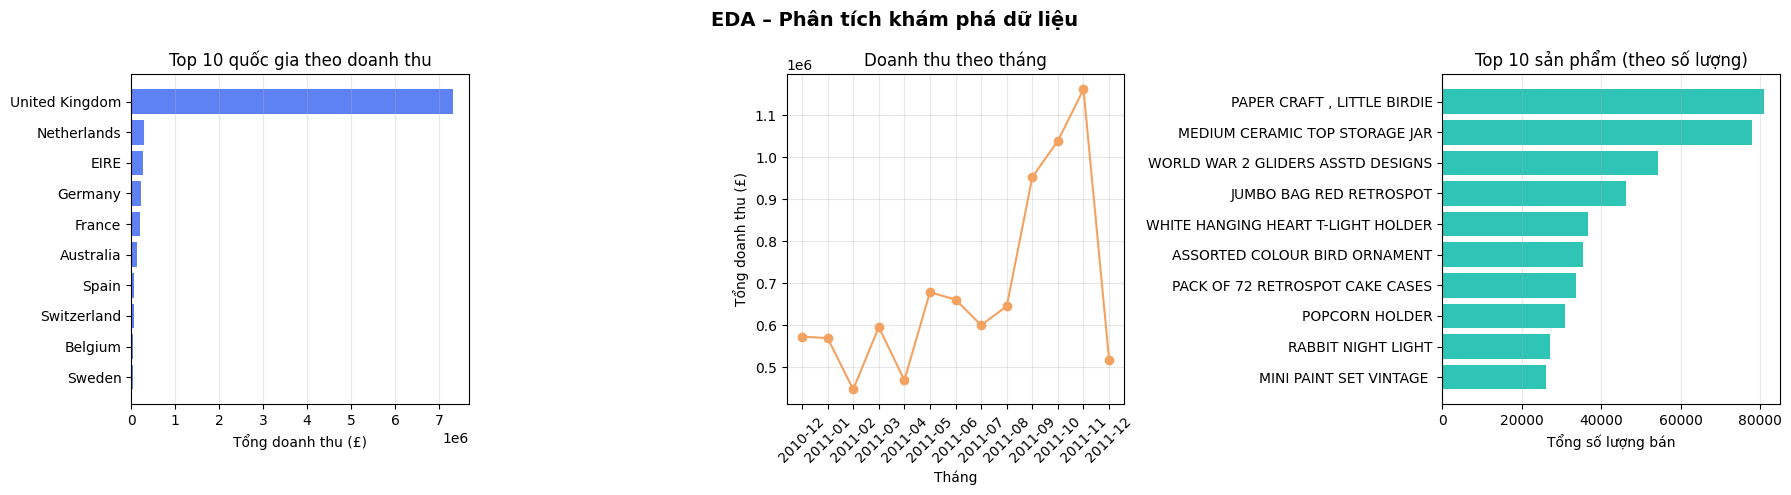

[EDA] Hoàn tất.

BƯỚC 3: XÂY DỰNG ĐẶC TRƯNG RFM
  Ngày mốc phân tích : 2011-12-10
  Số khách hàng RFM  : 4338


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total
0,12346,326,1,77183.60,1,1,5,115,7
1,12347,2,7,4310.00,5,5,5,555,15
2,12348,75,4,1797.24,2,4,4,244,10
3,12349,19,1,1757.55,4,1,4,414,9
4,12350,310,1,334.40,1,1,2,112,4
5,12352,36,8,2506.04,3,5,5,355,13
6,12353,204,1,89.00,1,1,1,111,3
7,12354,232,1,1079.40,1,1,4,114,6
8,12355,214,1,459.40,1,1,2,112,4
9,12356,23,3,2811.43,4,3,5,435,12


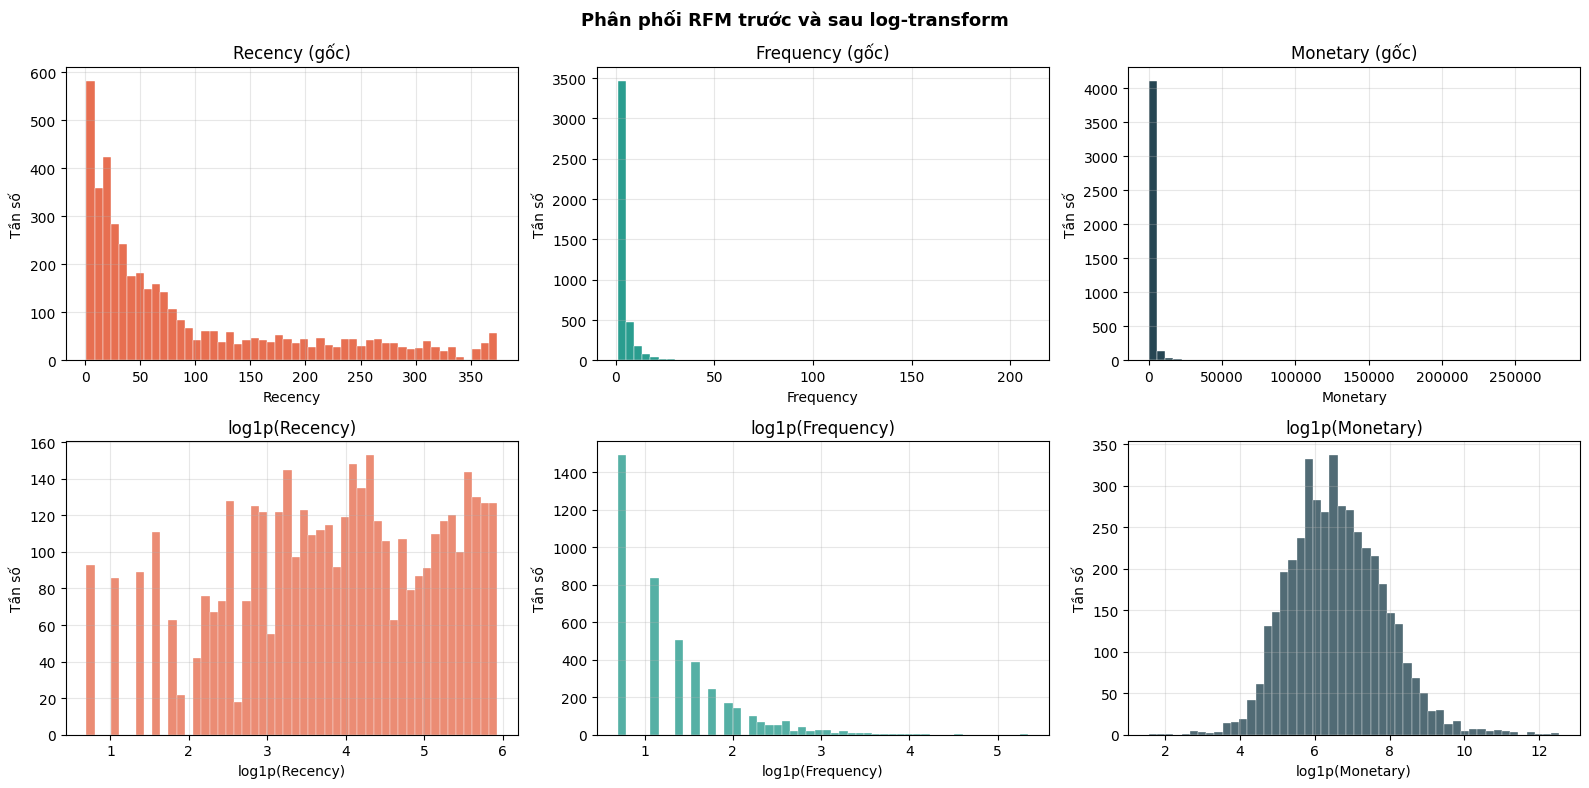


BƯỚC 4: PHÁT HIỆN VÀ LOẠI NGOẠI LỆ


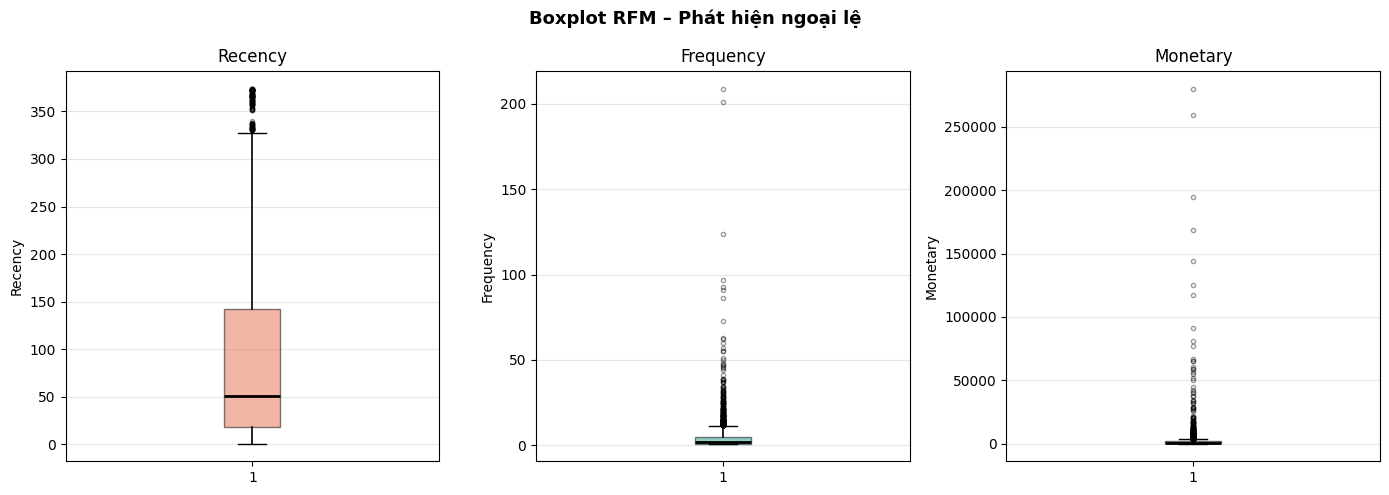


--- Loại outlier cực đoan (IQR × 3.0, chỉ Monetary) ---
  [Monetary] IQR×3.0: loại 222 khách hàng (ngoài [-3755.6, 5724.7])
  → Trước: 4338 | Sau: 4116 khách hàng

BƯỚC 5: CHUẨN HÓA + ĐÁNH GIÁ K TỐI ƯU

  K tốt nhất theo Silhouette : 2
  K gợi ý theo Elbow          : 5


,K,WCSS/Inertia,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,2,6125.62,0.4260,0.9050,4179.0
1,3,4721.12,0.3174,1.1265,3322.3
2,4,3738.43,0.3323,1.0190,3156.6
3,5,3210.73,0.3119,1.0464,2924.9
4,6,2761.40,0.3069,0.9920,2853.7
5,7,2504.59,0.2798,1.0046,2691.5
6,8,2308.49,0.2756,1.0278,2552.2
7,9,2118.77,0.2799,1.0298,2478.5
8,10,1967.21,0.2750,1.0442,2407.5


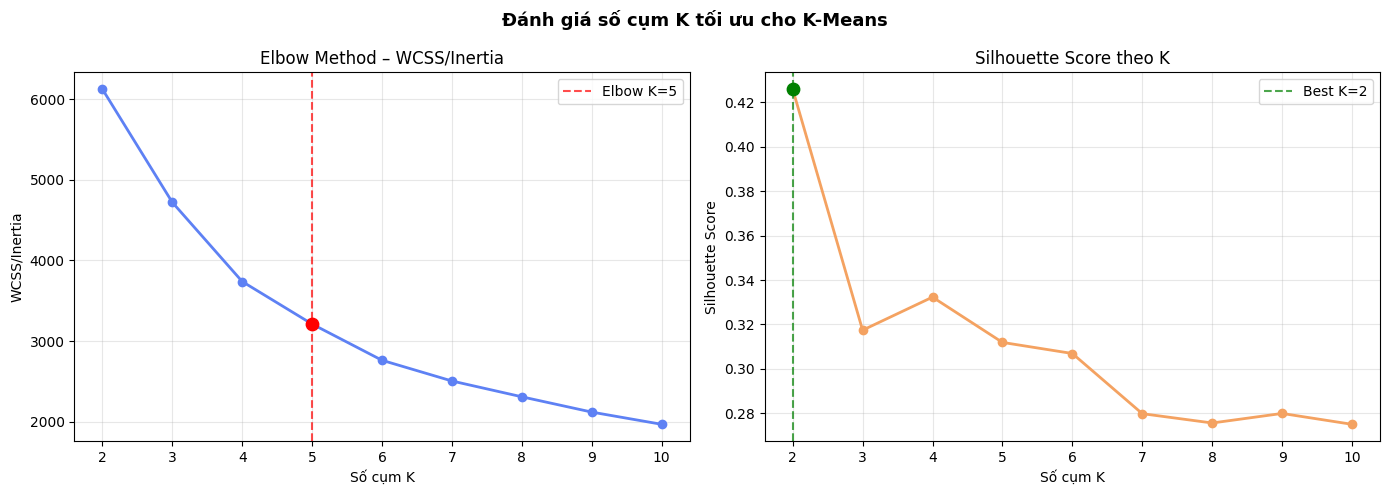


BƯỚC 6: K-MEANS CLUSTERING

  Đánh giá K-Means (K=2):
    Thuật toán: K-Means
    Số cụm thực tế: 2
    Số điểm nhiễu (-1): 0
    Tỷ lệ nhiễu (%): 0.0
    Silhouette: 0.426
    Davies_Bouldin: 0.905
    Calinski_Harabasz: 4179.0

--- Hồ sơ phân khúc K-Means ---


,Cluster,CustomerCount,Recency_mean,Frequency_mean,Monetary_mean,RFM_Total_mean,CustomerPercent,SegmentName,MarketingStrategy
0,0,2459,139.53,1.54,439.16,6.33,59.74,Khách hàng có nguy cơ rời bỏ,"Gửi ưu đãi quay lại, email nhắc mua, khảo sát ..."
1,1,1657,32.27,5.90,1999.56,12.27,40.26,Khách hàng VIP / Trung thành,"Ưu tiên chăm sóc riêng, chương trình thành viê..."


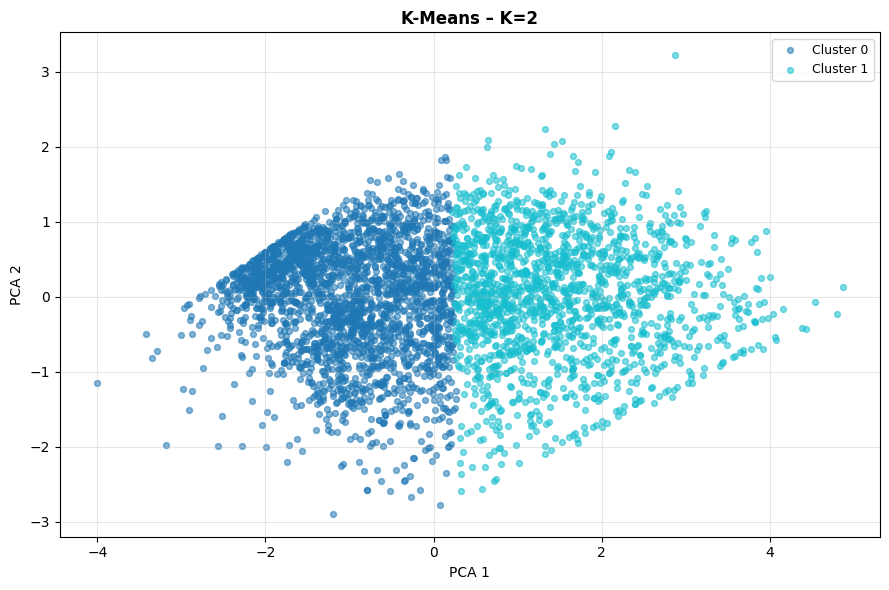

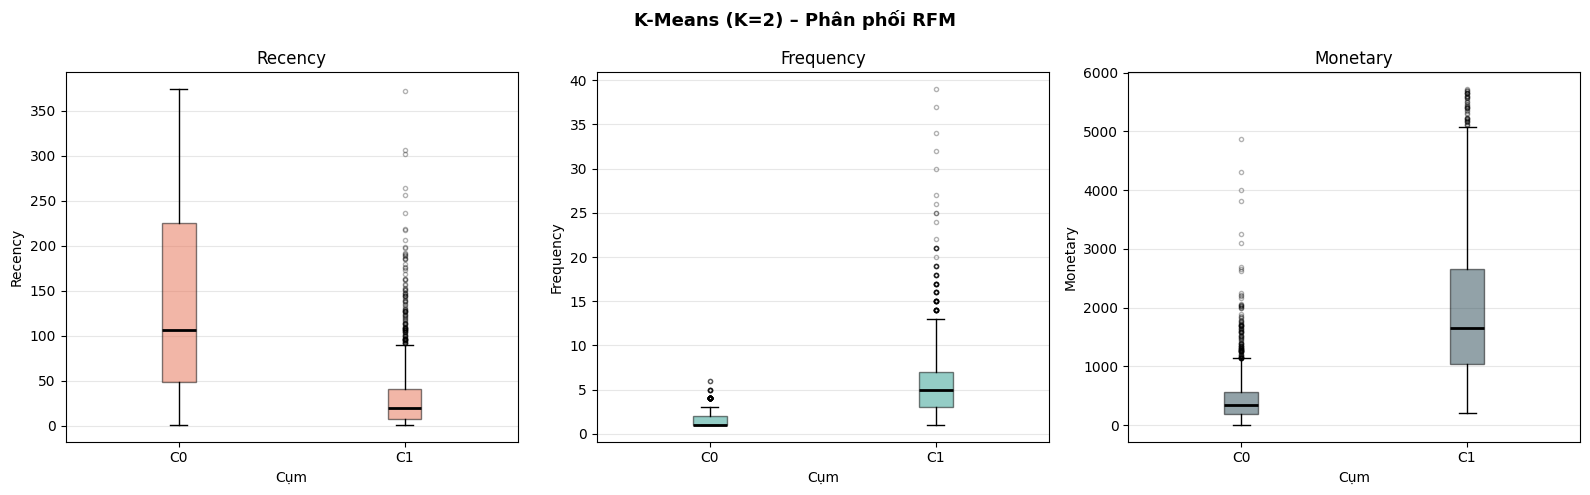

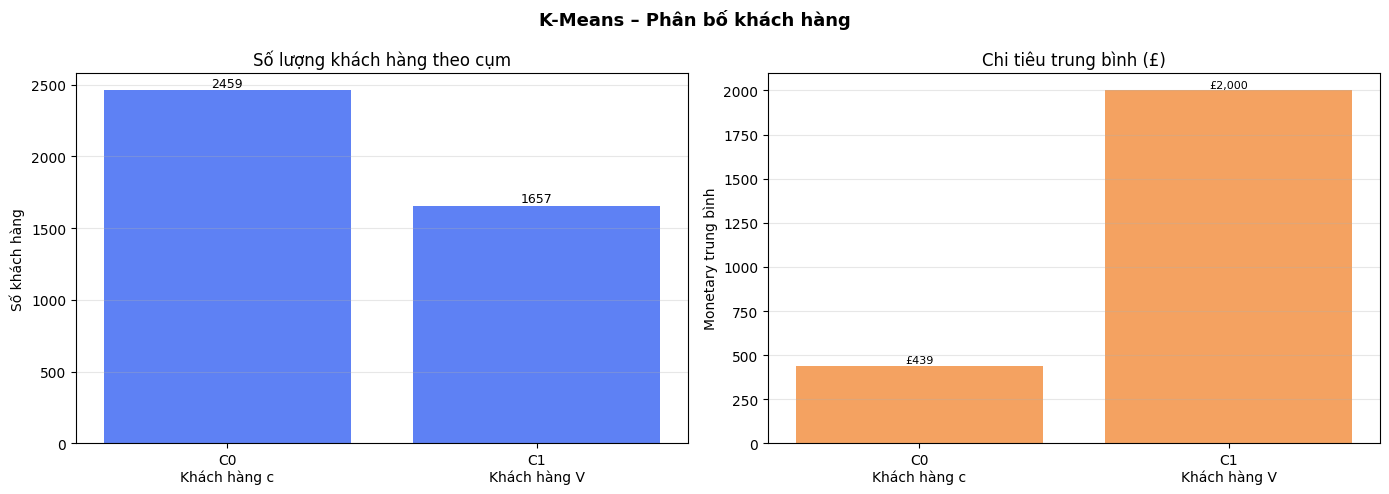

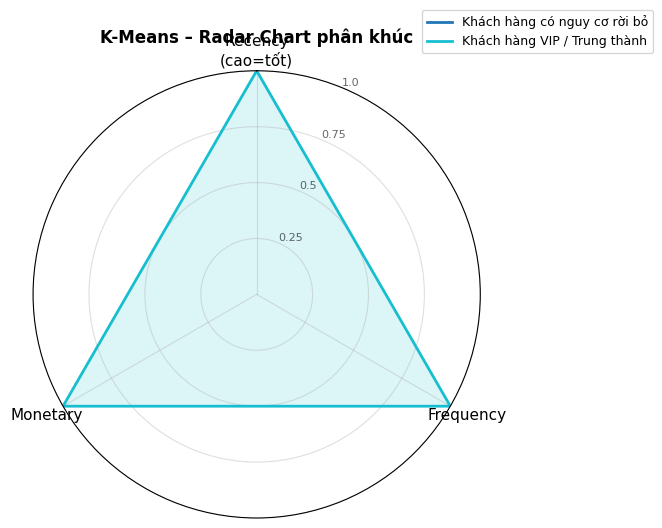


BƯỚC 7: DBSCAN CLUSTERING


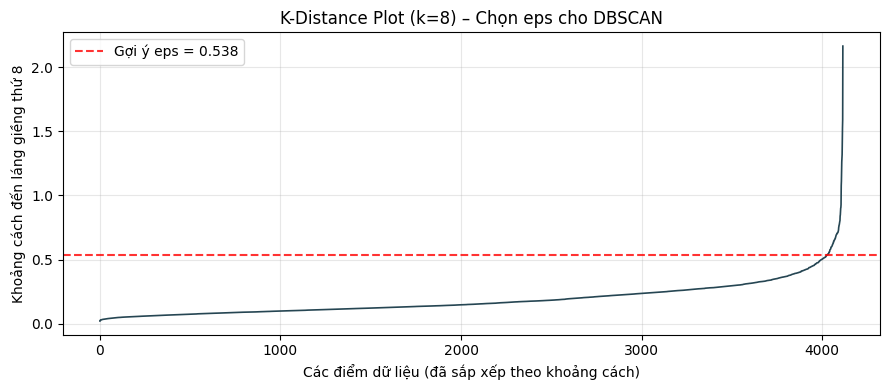

  Eps gợi ý: 0.5381  — Điều chỉnh nếu cần sau khi xem đồ thị.

  Đánh giá DBSCAN (eps=0.538, min_samples=8):
    Thuật toán: DBSCAN
    Số cụm thực tế: 2
    Số điểm nhiễu (-1): 26
    Tỷ lệ nhiễu (%): 0.63
    Silhouette: 0.3155
    Davies_Bouldin: 1.0502
    Calinski_Harabasz: 2532.8

--- Hồ sơ phân khúc DBSCAN (đã loại nhiễu -1) ---


,Cluster,CustomerCount,Recency_mean,Frequency_mean,Monetary_mean,RFM_Total_mean,CustomerPercent,SegmentName,MarketingStrategy
0,0,2608,62.12,4.53,1468.34,10.66,63.77,Khách hàng VIP / Trung thành,"Ưu tiên chăm sóc riêng, chương trình thành viê..."
1,1,1482,156.96,1.00,350.37,5.29,36.23,Khách hàng có nguy cơ rời bỏ,"Gửi ưu đãi quay lại, email nhắc mua, khảo sát ..."


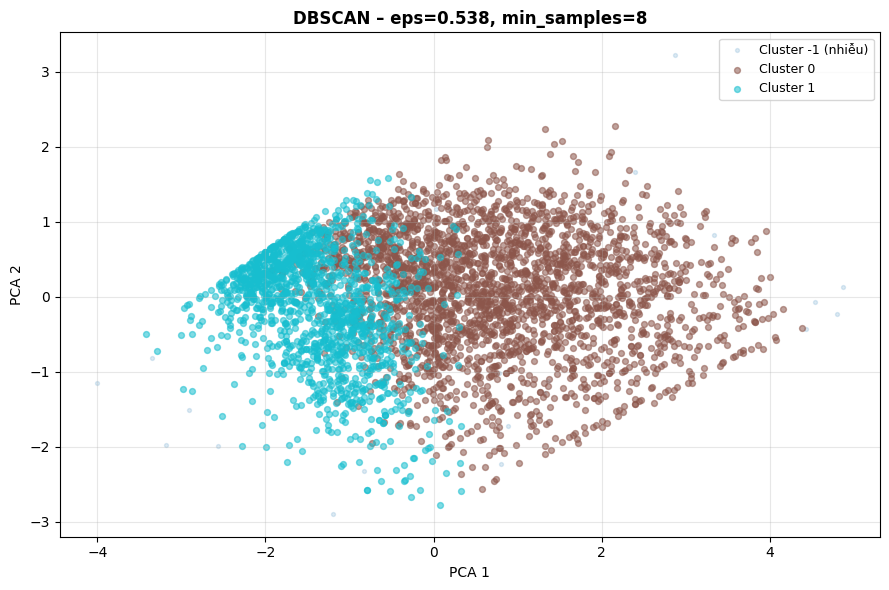

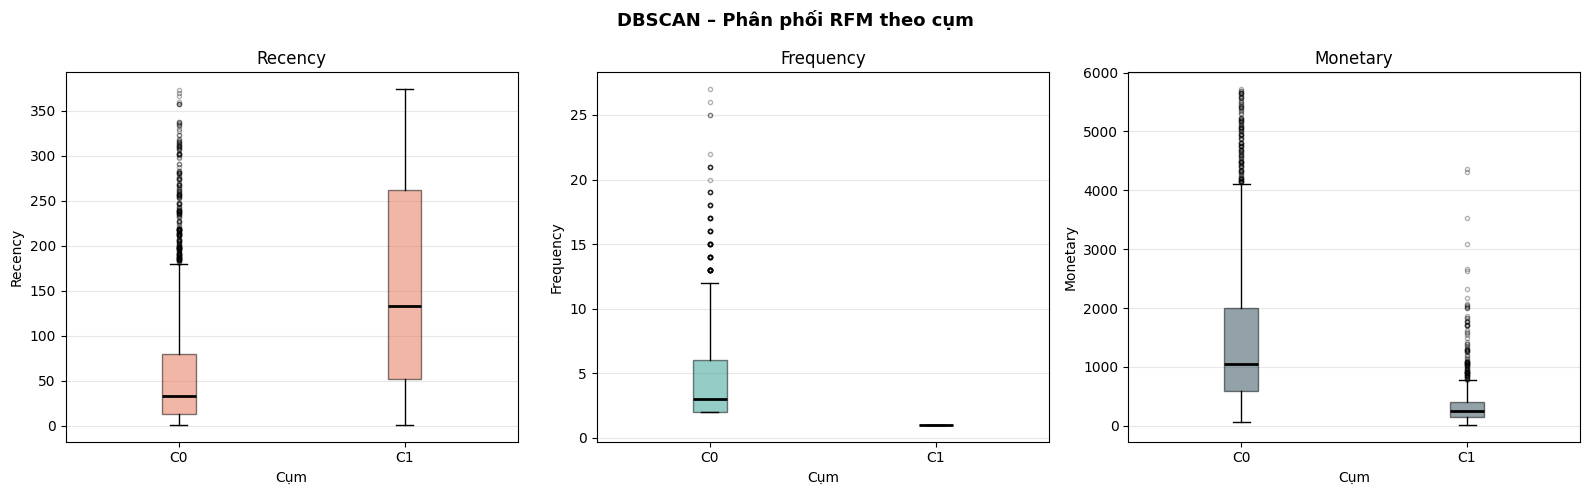

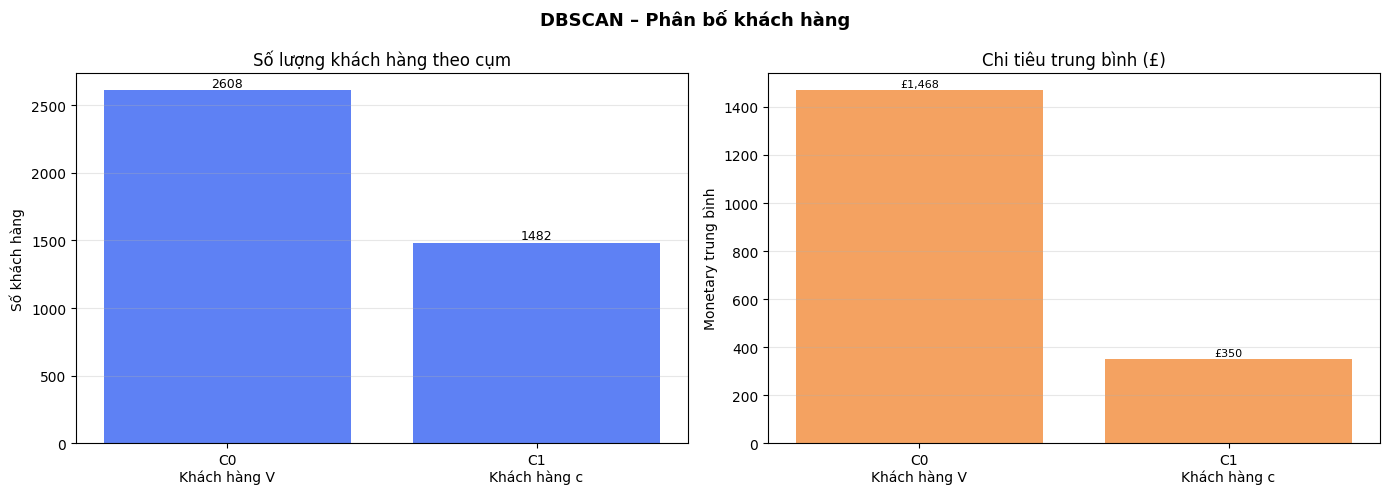

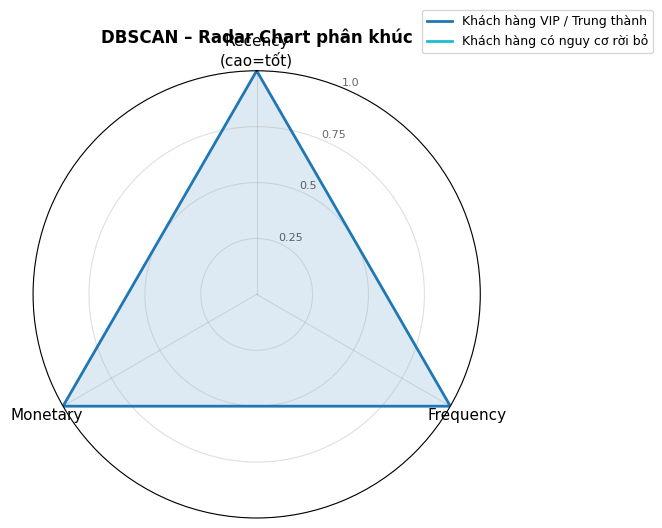


BƯỚC 8: SO SÁNH K-MEANS vs DBSCAN

========== SO SÁNH K-MEANS vs DBSCAN ==========
            Chỉ số  K-Means    DBSCAN
    Số cụm thực tế    2.000    2.0000
Số điểm nhiễu (-1)    0.000   26.0000
   Tỷ lệ nhiễu (%)    0.000    0.6300
        Silhouette    0.426    0.3155
    Davies_Bouldin    0.905    1.0502
 Calinski_Harabasz 4179.000 2532.8000

Ghi chú: Silhouette & Calinski_Harabasz càng cao càng tốt; Davies_Bouldin càng thấp càng tốt.


,Chỉ số,K-Means,DBSCAN
0,Số cụm thực tế,2.000,2.0000
1,Số điểm nhiễu (-1),0.000,26.0000
2,Tỷ lệ nhiễu (%),0.000,0.6300
3,Silhouette,0.426,0.3155
4,Davies_Bouldin,0.905,1.0502
5,Calinski_Harabasz,4179.000,2532.8000


In [ ]:
if not os.path.exists(DATA_PATH):
    print("⚠ Chưa tìm thấy file. Hãy upload ở ô 3 rồi chạy lại.")
else:
    # ── Bước 1: Đọc & Làm sạch ──────────────────────────────────────────────
    print("=" * 60)
    print("BƯỚC 1: ĐỌC VÀ LÀM SẠCH DỮ LIỆU")
    print("=" * 60)
    raw_df   = read_online_retail(DATA_PATH)
    clean_df, cleaning_report = clean_online_retail(raw_df)
    print("\n--- Báo cáo làm sạch ---")
    for k, v in cleaning_report.items():
        print(f"  {k}: {v}")

    # ── Bước 2: EDA ─────────────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print("BƯỚC 2: EDA – PHÂN TÍCH KHÁM PHÁ")
    print("=" * 60)
    plot_eda(clean_df)

    # ── Bước 3: RFM ─────────────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print("BƯỚC 3: XÂY DỰNG ĐẶC TRƯNG RFM")
    print("=" * 60)
    rfm, snapshot_date = build_rfm(clean_df)
    print(f"  Ngày mốc phân tích : {snapshot_date.date()}")
    print(f"  Số khách hàng RFM  : {len(rfm)}")
    display(rfm[["CustomerID","Recency","Frequency","Monetary",
                 "R_Score","F_Score","M_Score","RFM_Score","RFM_Total"]].head(10))
    plot_rfm_distribution(rfm)

    # ── Bước 4: Outlier ─────────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print("BƯỚC 4: PHÁT HIỆN VÀ LOẠI NGOẠI LỆ")
    print("=" * 60)
    plot_outlier_boxplot(rfm)
    print("\n--- Loại outlier cực đoan (IQR × 3.0, chỉ Monetary) ---")
    rfm_clean = remove_outliers_iqr(rfm, cols=["Monetary"], factor=3.0)

    # ── Bước 5: Chuẩn hóa + Elbow/Silhouette ────────────────────────────────
    print("\n" + "=" * 60)
    print("BƯỚC 5: CHUẨN HÓA + ĐÁNH GIÁ K TỐI ƯU")
    print("=" * 60)
    features, features_log, X_scaled, scaler = prepare_features(rfm_clean)
    eval_df, best_k, elbow_k = evaluate_kmeans(X_scaled, k_min=2, k_max=10)
    print(f"\n  K tốt nhất theo Silhouette : {best_k}")
    print(f"  K gợi ý theo Elbow          : {elbow_k}")
    display(eval_df)
    plot_kmeans_evaluation(eval_df, best_k=best_k, elbow_k=elbow_k)

    # ── Bước 6: K-Means ─────────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print("BƯỚC 6: K-MEANS CLUSTERING")
    print("=" * 60)
    chosen_k = best_k  # đổi thành elbow_k nếu muốn
    kmeans_result, kmeans_model = run_kmeans(rfm_clean, X_scaled, n_clusters=chosen_k)
    kmeans_metrics = evaluate_clustering(X_scaled, kmeans_result["Cluster"], "K-Means")
    print(f"\n  Đánh giá K-Means (K={chosen_k}):")
    for k, v in kmeans_metrics.items():
        print(f"    {k}: {v}")

    kmeans_pca, _  = add_pca_columns(kmeans_result, X_scaled)
    kmeans_profile = summarize_clusters(kmeans_result)
    print("\n--- Hồ sơ phân khúc K-Means ---")
    display(kmeans_profile)
    plot_pca_clusters(kmeans_pca,          title=f"K-Means – K={chosen_k}")
    plot_rfm_boxplot_by_cluster(kmeans_result, title=f"K-Means (K={chosen_k}) – Phân phối RFM")
    plot_cluster_bar(kmeans_profile,       title="K-Means – Phân bố khách hàng")
    plot_radar_chart(kmeans_profile,       title="K-Means – Radar Chart phân khúc")

    # ── Bước 7: DBSCAN ──────────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print("BƯỚC 7: DBSCAN CLUSTERING")
    print("=" * 60)
    suggested_eps, _ = suggest_dbscan_eps(X_scaled, min_samples=8)
    dbscan_result, dbscan_model = run_dbscan(rfm_clean, X_scaled,
                                              eps=suggested_eps, min_samples=8)
    dbscan_metrics = evaluate_clustering(X_scaled, dbscan_result["Cluster"], "DBSCAN")
    print(f"\n  Đánh giá DBSCAN (eps={suggested_eps:.3f}, min_samples=8):")
    for k, v in dbscan_metrics.items():
        print(f"    {k}: {v}")

    dbscan_pca, _  = add_pca_columns(dbscan_result, X_scaled)
    dbscan_profile = summarize_clusters(dbscan_result)
    print("\n--- Hồ sơ phân khúc DBSCAN (đã loại nhiễu -1) ---")
    display(dbscan_profile)
    plot_pca_clusters(dbscan_pca, title=f"DBSCAN – eps={suggested_eps:.3f}, min_samples=8")
    plot_rfm_boxplot_by_cluster(dbscan_result, title="DBSCAN – Phân phối RFM theo cụm")
    if len(dbscan_profile) > 0:
        plot_cluster_bar(dbscan_profile,  title="DBSCAN – Phân bố khách hàng")
        plot_radar_chart(dbscan_profile,  title="DBSCAN – Radar Chart phân khúc")

    # ── Bước 8: So sánh ─────────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print("BƯỚC 8: SO SÁNH K-MEANS vs DBSCAN")
    print("=" * 60)
    comparison_df = compare_algorithms(kmeans_metrics, dbscan_metrics)
    display(comparison_df)

## 16. Giao diện Gradio
Cho phép upload file, chọn thuật toán và xem kết quả mà không cần chạy từng ô.
- Tương thích **Gradio v4+** (đã sửa lỗi `file.name` deprecated).
- Checkbox để bật/tắt loại outlier trước khi clustering.

In [ ]:
def make_pca_figure(result_with_pca, title):
    labels = sorted(result_with_pca["Cluster"].unique())
    cmap   = plt.cm.get_cmap("tab10", max(len(labels), 1))
    fig, ax = plt.subplots(figsize=(8, 5))
    for i, lab in enumerate(labels):
        mask = result_with_pca["Cluster"] == lab
        ax.scatter(result_with_pca.loc[mask, "PCA1"],
                   result_with_pca.loc[mask, "PCA2"],
                   c=[cmap(i)],
                   label=f"Cluster {lab}" + (" (nhiễu)" if lab == -1 else ""),
                   alpha=0.6 if lab != -1 else 0.15, s=18)
    ax.set_title(title); ax.set_xlabel("PCA 1"); ax.set_ylabel("PCA 2")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    fig.tight_layout()
    return fig


def make_bar_figure(profile):
    filtered = profile[profile["Cluster"] != -1].copy()
    fig, ax  = plt.subplots(figsize=(8, 4))
    ax.bar(filtered["Cluster"].astype(str), filtered["CustomerCount"], color="#5E81F4")
    ax.set_title("Số lượng khách hàng theo cụm")
    ax.set_xlabel("Cluster"); ax.set_ylabel("Số khách hàng")
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    return fig


def pipeline_gradio(file, algorithm, k, eps, min_samples, max_k, remove_outliers_flag):
    if file is None:
        raise gr.Error("Vui lòng upload file Online Retail.xlsx")

    # Tương thích Gradio v3 (file.name) và v4+ (string path)
    file_path = file if isinstance(file, str) else file.name

    raw   = read_online_retail(file_path)
    clean, cleaning_report = clean_online_retail(raw)
    rfm_raw, snapshot_date = build_rfm(clean)

    rfm_use = remove_outliers_iqr(rfm_raw, cols=["Monetary"], factor=3.0)               if remove_outliers_flag else rfm_raw

    features, features_log, X_scaled, scaler = prepare_features(rfm_use)
    eval_df, best_k, elbow_k = evaluate_kmeans(X_scaled, k_min=2, k_max=int(max_k))

    if algorithm == "K-Means":
        chosen_k      = int(k) if int(k) > 1 else best_k
        result, model = run_kmeans(rfm_use, X_scaled, n_clusters=chosen_k)
        title         = f"K-Means – K={chosen_k}"
    else:
        if eps <= 0:
            suggested_eps, _ = suggest_dbscan_eps(X_scaled, min_samples=int(min_samples))
            eps = suggested_eps
        result, model = run_dbscan(rfm_use, X_scaled,
                                    eps=float(eps), min_samples=int(min_samples))
        title = f"DBSCAN – eps={eps:.3f}, min_samples={int(min_samples)}"

    metrics   = evaluate_clustering(X_scaled, result["Cluster"], algorithm)
    profile   = summarize_clusters(result)
    result_pca, _ = add_pca_columns(result, X_scaled)

    pca_fig = make_pca_figure(result_pca, title)
    bar_fig = make_bar_figure(profile)

    output_path = "rfm_clustering_result.csv"
    result.to_csv(output_path, index=False, encoding="utf-8-sig")

    lines = ["# Kết quả phân khúc khách hàng", "",
             "## Làm sạch dữ liệu"]
    for key, val in cleaning_report.items():
        lines.append(f"- **{key}**: {val}")
    lines += [f"- **Ngày mốc RFM**: {snapshot_date.date()}",
              f"- **Loại outlier**: {'Có' if remove_outliers_flag else 'Không'}",
              "", "## Gợi ý K cho K-Means",
              f"- **K tốt nhất theo Silhouette**: {best_k}",
              f"- **K gợi ý theo Elbow**: {elbow_k}",
              "", f"## Đánh giá: {algorithm}"]
    for key, val in metrics.items():
        lines.append(f"- **{key}**: {val}")
    lines.append("\n> Silhouette & Calinski càng cao càng tốt; "
                 "Davies-Bouldin càng thấp càng tốt.")
    return "\n".join(lines), eval_df, profile, pca_fig, bar_fig, output_path


with gr.Blocks(title="RFM Segmentation – K-Means & DBSCAN") as demo:
    gr.Markdown("# Phân khúc khách hàng RFM – K-Means & DBSCAN\n"
                "Upload `Online Retail.xlsx`, chọn thuật toán, bấm **Chạy phân tích**.")

    with gr.Row():
        file_input = gr.File(label="Upload Online Retail.xlsx", file_types=[".xlsx",".xls"])
        algorithm  = gr.Radio(["K-Means","DBSCAN"], value="K-Means", label="Thuật toán")

    with gr.Row():
        k     = gr.Slider(2, 10, value=4, step=1, label="Số cụm K (K-Means)")
        max_k = gr.Slider(4, 15, value=10, step=1, label="K tối đa đánh giá")

    with gr.Row():
        eps         = gr.Number(value=0, label="eps DBSCAN (≤ 0 = tự gợi ý)")
        min_samples = gr.Slider(3, 30, value=8, step=1, label="min_samples DBSCAN")
        remove_out  = gr.Checkbox(value=True, label="Loại outlier Monetary trước clustering")

    run_btn = gr.Button("▶ Chạy phân tích", variant="primary")

    report_out  = gr.Markdown(label="Báo cáo")
    eval_out    = gr.Dataframe(label="Bảng đánh giá K (WCSS · Silhouette · DB · CH)")
    profile_out = gr.Dataframe(label="Hồ sơ phân khúc + Chiến lược Marketing")

    with gr.Row():
        pca_plot = gr.Plot(label="Biểu đồ PCA 2D")
        bar_plot = gr.Plot(label="Số lượng khách hàng theo cụm")

    dl_out = gr.File(label="Tải kết quả CSV")

    run_btn.click(
        fn=pipeline_gradio,
        inputs=[file_input, algorithm, k, eps, min_samples, max_k, remove_out],
        outputs=[report_out, eval_out, profile_out, pca_plot, bar_plot, dl_out],
    )

# share=True để các thành viên trong nhóm mở được link tạm thời trên Colab
demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://d3b1438b520f89b140.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


  [Monetary] IQR×3.0: loại 222 khách hàng (ngoài [-3755.6, 5724.7])
  → Trước: 4338 | Sau: 4116 khách hàng
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://d3b1438b520f89b140.gradio.live


## 17. Gợi ý trình bày kết quả trong báo cáo cuối kỳ

### Chương 4 – Thực nghiệm và Kết quả nên bao gồm:

| # | Hình/Bảng | Lấy từ bước |
|---|-----------|------------|
| 1 | Bảng thống kê dữ liệu trước/sau làm sạch | Bước 1 |
| 2 | Biểu đồ EDA (quốc gia, doanh thu tháng, sản phẩm) | Bước 2 |
| 3 | Histogram R, F, M trước/sau log-transform | Bước 3 |
| 4 | Boxplot phát hiện ngoại lệ | Bước 4 |
| 5 | Biểu đồ Elbow Method + Silhouette Score | Bước 5 |
| 6 | Biểu đồ K-Distance Plot → chọn eps DBSCAN | Bước 7 |
| 7 | PCA 2D – K-Means và DBSCAN (so sánh cạnh nhau) | Bước 6 & 7 |
| 8 | Boxplot RFM theo cụm (K-Means và DBSCAN) | Bước 6 & 7 |
| 9 | Radar Chart hồ sơ phân khúc | Bước 6 & 7 |
| 10 | Bảng so sánh metrics K-Means vs DBSCAN | Bước 8 |
| 11 | Bảng diễn giải phân khúc + Chiến lược Marketing | Bước 6 & 7 |

### Kết luận nên trả lời:
- Thuật toán nào cho Silhouette Score cao hơn?
- DBSCAN phát hiện bao nhiêu % điểm nhiễu?
- Phân khúc nào chiếm nhiều khách hàng nhất? Chiến lược Marketing tương ứng?
- Hạn chế và hướng phát triển tiếp theo.